In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU. Check Runtime → Change runtime type → GPU")

CUDA available: True
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
import os

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/OCR project"

print(os.listdir(DRIVE_PROJECT_DIR))

['modelling v1.ipynb', 'sentences_augmented.csv', 'lines flattened augmented.zip']


In [7]:
import os
import shutil
import zipfile

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/OCR project"
LOCAL_PROJECT_DIR = "/content/ocr_project"

os.makedirs(LOCAL_PROJECT_DIR, exist_ok=True)

ZIP_NAME = "lines flattened augmented.zip"
CSV_NAME = "sentences_augmented.csv"

ZIP_DRIVE_PATH = os.path.join(DRIVE_PROJECT_DIR, ZIP_NAME)
CSV_DRIVE_PATH = os.path.join(DRIVE_PROJECT_DIR, CSV_NAME)

ZIP_LOCAL_PATH = os.path.join(LOCAL_PROJECT_DIR, ZIP_NAME)
CSV_LOCAL_PATH = os.path.join(LOCAL_PROJECT_DIR, CSV_NAME)

shutil.copy2(ZIP_DRIVE_PATH, ZIP_LOCAL_PATH)
shutil.copy2(CSV_DRIVE_PATH, CSV_LOCAL_PATH)

print("Copied ZIP:", os.path.exists(ZIP_LOCAL_PATH))
print("Copied CSV:", os.path.exists(CSV_LOCAL_PATH))

Copied ZIP: True
Copied CSV: True


In [8]:
with zipfile.ZipFile(ZIP_LOCAL_PATH, "r") as zip_ref:
    zip_ref.extractall(LOCAL_PROJECT_DIR)

print("Files/folders in local project directory:")
print(os.listdir(LOCAL_PROJECT_DIR))

Files/folders in local project directory:
['lines flattened augmented.zip', 'lines flattened augmented', 'sentences_augmented.csv']


In [9]:
CSV_PATH = "/content/ocr_project/sentences_augmented.csv"
IMAGE_DIR = "/content/ocr_project/lines flattened augmented"

print("CSV exists:", os.path.exists(CSV_PATH))
print("Image folder exists:", os.path.exists(IMAGE_DIR))

if os.path.exists(IMAGE_DIR):
    print("Number of images:", len(os.listdir(IMAGE_DIR)))
    print("First 5 images:", os.listdir(IMAGE_DIR)[:5])

CSV exists: True
Image folder exists: True
Number of images: 14253
First 5 images: ['d06-063-08.png', 'k03-117-08.png', 'p02-069-08.png', 'c04-039-00__rotation.png', 'l04-102-04.png']


In [10]:
from PIL import Image
import pandas as pd
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torch.nn.utils.rnn import pad_sequence
import os
import string
import torch.nn.functional as F# needed to create output
import torch.nn as nn
from sklearn.model_selection import train_test_split

In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd

CSV_PATH = "/content/ocr_project/sentences_augmented.csv"
IMAGE_DIR = "/content/ocr_project/lines flattened augmented"

sentences = pd.read_csv(CSV_PATH)

sentences["id"] = sentences["id"].astype(str)
sentences["sentence"] = sentences["sentence"].astype(str)
sentences["original_id"] = sentences["original_id"].astype(str)
sentences["augmentation"] = sentences["augmentation"].astype(str)

print(sentences.head())
print(sentences.columns)
print(sentences["augmentation"].value_counts())

                id                               sentence  original_id  \
0  a01-000u-00.png      A MOVE to stop Mr. Gaitskell from  a01-000u-00   
1  a01-000u-01.png  nominating any more Labour life Peers  a01-000u-01   
2  a01-000u-02.png   is to be made at a meeting of Labour  a01-000u-02   
3  a01-000u-03.png      Ps tomorrow. Mr. Michael Foot has  a01-000u-03   
4  a01-000u-04.png   put down a resolution on the subject  a01-000u-04   

  augmentation  
0     original  
1     original  
2     original  
3     original  
4     original  
Index(['id', 'sentence', 'original_id', 'augmentation'], dtype='object')
augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
blur                100
affine              100
erosion             100
dilation            100
scale_resize        100
sharpen             100
Name: count, dtype: int64


In [ ]:
print(sentences["augmentation"].value_counts())

augmentation
original          13353
gaussian_noise      100
rotation            100
compression         100
blur                100
affine              100
erosion             100
dilation            100
scale_resize        100
sharpen             100
Name: count, dtype: int64


In [12]:
# Separate original and augmented rows
original_rows = sentences[sentences["augmentation"] == "original"].copy()
augmented_rows = sentences[sentences["augmentation"] != "original"].copy()

# These are original IDs that have at least one augmented version
augmented_original_ids = set(augmented_rows["original_id"].unique())

# These original IDs must be forced into train
# because their augmented versions also exist
print("Original IDs with augmentations:", len(augmented_original_ids))

# All original IDs in the dataset
all_original_ids = set(original_rows["original_id"].unique())

# Original IDs that are safe to use for validation/test
# because they have no augmented version
non_augmented_original_ids = sorted(list(all_original_ids - augmented_original_ids))

print("Original IDs without augmentations:", len(non_augmented_original_ids))

# Split only the non-augmented original IDs into train/val/test
train_extra_ids, temp_ids = train_test_split(
    non_augmented_original_ids,
    test_size=0.30,
    random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42
)

# Final train IDs:
# 1. all IDs that have augmentations
# 2. additional normal original IDs from the split
train_ids = set(train_extra_ids) | augmented_original_ids
val_ids = set(val_ids)
test_ids = set(test_ids)

# Build final dataframes
# Train contains original + augmented rows
train = sentences[sentences["original_id"].isin(train_ids)].reset_index(drop=True)

# Validation and test contain only original rows
val = original_rows[original_rows["original_id"].isin(val_ids)].reset_index(drop=True)
test = original_rows[original_rows["original_id"].isin(test_ids)].reset_index(drop=True)

# Leakage checks
assert set(train["original_id"]).isdisjoint(set(val["original_id"]))
assert set(train["original_id"]).isdisjoint(set(test["original_id"]))
assert set(val["original_id"]).isdisjoint(set(test["original_id"]))

assert (val["augmentation"] == "original").all()
assert (test["augmentation"] == "original").all()

print("Train rows:", len(train))
print("Validation rows:", len(val))
print("Test rows:", len(test))

print("\nTrain augmentation distribution:")
print(train["augmentation"].value_counts())

print("\nValidation augmentation distribution:")
print(val["augmentation"].value_counts())

print("\nTest augmentation distribution:")
print(test["augmentation"].value_counts())

Original IDs with augmentations: 900
Original IDs without augmentations: 12453
Train rows: 10517
Validation rows: 1868
Test rows: 1868

Train augmentation distribution:
augmentation
original          9617
gaussian_noise     100
rotation           100
compression        100
blur               100
affine             100
erosion            100
dilation           100
scale_resize       100
sharpen            100
Name: count, dtype: int64

Validation augmentation distribution:
augmentation
original    1868
Name: count, dtype: int64

Test augmentation distribution:
augmentation
original    1868
Name: count, dtype: int64


In [13]:
# define the output labels


CHARS = (
    string.ascii_lowercase +
    string.ascii_uppercase +
    string.digits +
    string.punctuation +
    " "
)

print(len(CHARS))
print(CHARS)


# create mappings

char2idx = {c: i + 1 for i, c in enumerate(CHARS)}  # 0 reserved
idx2char = {i: c for c, i in char2idx.items()}

# add UNK token
char2idx["<UNK>"] = len(char2idx) + 1

# test mappings
print(char2idx["a"])
print(char2idx[" "])
print(char2idx["<UNK>"])

95
abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~ 
1
95
96


In [14]:
# create custom dataset

class OCRDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, id_col="id", text_col="sentence"):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = image_dir
        self.transform = transform

        self.ids = self.df[id_col].astype(str).values
        self.texts = self.df[text_col].astype(str).values

        self.char2idx = char2idx

    def encode(self, text):
        encoded = []

        for c in str(text):
            if c in self.char2idx:
                encoded.append(self.char2idx[c])
            else:
                encoded.append(self.char2idx["<UNK>"])

        return torch.tensor(encoded, dtype=torch.long)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        text = self.texts[idx]

        img_path = os.path.join(self.img_dir, img_id)

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"{img_path} not found")

        try:
            image = Image.open(img_path).convert("L")
        except Exception as e:
            raise RuntimeError(f"Error loading {img_path}: {e}")

        if self.transform:
            image = self.transform(image)

        encoded = self.encode(text)

        return image, encoded

In [15]:
# we need to keep aspekt ratio. height can be stable, but if we resize width tot the same size, training will be silly

class ResizeHeight:
    def __init__(self, height):
        self.height = height

    def __call__(self, img):
        w, h = img.size
        new_h = self.height
        new_w = int(w * (new_h / h))
        return img.resize((new_w, new_h))

In [16]:
# test it a bit

transform_ocr = transforms.Compose([
    ResizeHeight(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = OCRDataset(
    df=train,
    image_dir=IMAGE_DIR,
    transform=transform_ocr,
    id_col="id",
    text_col="sentence"
)

val_dataset = OCRDataset(
    df=val,
    image_dir=IMAGE_DIR,
    transform=transform_ocr,
    id_col="id",
    text_col="sentence"
)

test_dataset = OCRDataset(
    df=test,
    image_dir=IMAGE_DIR,
    transform=transform_ocr,
    id_col="id",
    text_col="sentence"
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 10517
Validation dataset: 1868
Test dataset: 1868


In [17]:
image, encoded = train_dataset[0]

print(type(encoded))
print(encoded)
print(encoded.shape)

print("Image shape:", image.shape)
print("Space index:", char2idx[" "])

print(train_dataset.encode("hello€"))

<class 'torch.Tensor'>
tensor([14, 15, 13,  9, 14,  1, 20,  9, 14,  7, 95,  1, 14, 25, 95, 13, 15, 18,
         5, 95, 38,  1,  2, 15, 21, 18, 95, 12,  9,  6,  5, 95, 42,  5,  5, 18,
        19])
torch.Size([37])
Image shape: torch.Size([1, 64, 1127])
Space index: 95
tensor([ 8,  5, 12, 12, 15, 96])


In [18]:
def collate_fn_single(batch):
    image, label = batch[0]

    image = image.unsqueeze(0)          # [1, C, H, W]
    label = label.unsqueeze(0)          # [1, target_length]

    width = torch.tensor([image.shape[-1]], dtype=torch.long)
    target_length = torch.tensor([label.shape[1]], dtype=torch.long)

    return image, label, width, target_length


train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=collate_fn_single
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn_single
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn_single
)

In [19]:
images, labels, widths, target_lengths = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Widths:", widths)
print("Target lengths:", target_lengths)

Images shape: torch.Size([1, 1, 64, 785])
Labels shape: torch.Size([1, 45])
Widths: tensor([785])
Target lengths: tensor([45])


In [20]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # H/2, W/2

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),               # H/4, W/4

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),             # H/8, W/4

            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d((2, 1))              # H/16, W/4
        )

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # x: (B, 1, H, W)
        x = self.cnn(x)                              # (B, 512, H', W')
        x = F.adaptive_avg_pool2d(x, (1, x.size(3)))  # (B, 512, 1, W')
        x = x.squeeze(2)                             # (B, 512, W')
        x = x.permute(0, 2, 1)                       # (B, W', 512)

        x, _ = self.rnn(x)                           # (B, W', 512)
        x = self.fc(x)                               # (B, W', num_classes)
        log_probs = F.log_softmax(x, dim=2)

        return log_probs

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(char2idx) + 1   # +1 because blank=0 is reserved in CTC

model = CRNN(num_classes).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

print("Device:", device)
print("num_classes:", num_classes)

Device: cuda
num_classes: 97


In [22]:

ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

In [23]:
def greedy_decode(log_probs, idx2char, blank=0):
    # log_probs: (T, B, C)
    preds = log_probs.argmax(dim=2)  # (T, B)

    results = []
    T, B = preds.shape

    for b in range(B):
        seq = preds[:, b].detach().cpu().tolist()

        decoded = []
        prev = blank

        for s in seq:
            if s != blank and s != prev:
                decoded.append(idx2char.get(s, "?"))
            prev = s

        results.append("".join(decoded))

    return results

In [24]:
# loss fucntion

def compute_ctc_loss(model, images, labels, target_lengths):
    images = images.to(device)
    labels = labels.to(device)
    target_lengths = target_lengths.to(device)

    # model output: [B, T, C]
    log_probs = model(images)

    # CTC expects: [T, B, C]
    log_probs = log_probs.permute(1, 0, 2)

    T = log_probs.size(0)
    batch_size = log_probs.size(1)

    input_lengths = torch.full(
        size=(batch_size,),
        fill_value=T,
        dtype=torch.long,
        device=device
    )

    if (target_lengths > input_lengths).any():
        return None

    loss = ctc_loss(
        log_probs,
        labels,
        input_lengths,
        target_lengths
    )

    return loss

In [25]:
def train_one_epoch(model, loader, optimizer, accum_steps=16):
    model.train()

    total_loss = 0.0
    valid_batches = 0
    skipped_batches = 0
    accumulation_counter = 0

    optimizer.zero_grad()

    for images, labels, widths, target_lengths in loader:
        loss = compute_ctc_loss(
            model,
            images,
            labels,
            target_lengths
        )

        if loss is None:
            skipped_batches += 1
            continue

        # Divide the loss because gradients are accumulated over several samples
        (loss / accum_steps).backward()

        total_loss += loss.item()
        valid_batches += 1
        accumulation_counter += 1

        if accumulation_counter % accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()
            optimizer.zero_grad()

    # Final optimizer update if the number of valid samples is not divisible by accum_steps
    if accumulation_counter % accum_steps != 0:
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()
        optimizer.zero_grad()

    avg_loss = total_loss / max(valid_batches, 1)

    return avg_loss, skipped_batches


@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()

    total_loss = 0.0
    valid_batches = 0
    skipped_batches = 0

    for images, labels, widths, target_lengths in loader:
        loss = compute_ctc_loss(
            model,
            images,
            labels,
            target_lengths
        )

        if loss is None:
            skipped_batches += 1
            continue

        total_loss += loss.item()
        valid_batches += 1

    avg_loss = total_loss / max(valid_batches, 1)

    return avg_loss, skipped_batches

In [26]:
EPOCHS = 30
PATIENCE = 5
ACCUM_STEPS = 16

best_val_loss = float("inf")
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss, skipped_train = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        accum_steps=ACCUM_STEPS
    )

    val_loss, skipped_val = evaluate_loss(
        model=model,
        loader=val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Skipped train: {skipped_train} | "
        f"Skipped val: {skipped_val}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            "best_crnn_augmented.pt"
        )

        print("Best model saved.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping.")
        break

Epoch 1/30 | Train loss: 3.0925 | Val loss: 1.9858 | Skipped train: 0 | Skipped val: 0
Best model saved.
Epoch 2/30 | Train loss: 1.0256 | Val loss: 0.8799 | Skipped train: 0 | Skipped val: 0
Best model saved.
Epoch 3/30 | Train loss: 0.5807 | Val loss: 0.7390 | Skipped train: 0 | Skipped val: 0
Best model saved.
Epoch 4/30 | Train loss: 0.4292 | Val loss: 0.7048 | Skipped train: 0 | Skipped val: 0
Best model saved.
Epoch 5/30 | Train loss: 0.3347 | Val loss: 0.6526 | Skipped train: 0 | Skipped val: 0
Best model saved.
Epoch 6/30 | Train loss: 0.2684 | Val loss: 0.6225 | Skipped train: 0 | Skipped val: 0
Best model saved.
Epoch 7/30 | Train loss: 0.2115 | Val loss: 0.6145 | Skipped train: 0 | Skipped val: 0
Best model saved.
Epoch 8/30 | Train loss: 0.1658 | Val loss: 0.6500 | Skipped train: 0 | Skipped val: 0
Epoch 9/30 | Train loss: 0.1290 | Val loss: 0.7247 | Skipped train: 0 | Skipped val: 0
Epoch 10/30 | Train loss: 0.0976 | Val loss: 0.7555 | Skipped train: 0 | Skipped val: 0
Epo

In [33]:
import os
import shutil

DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/OCR project/checkpoints"
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

LOCAL_MODEL_PATH = "best_crnn_augmented.pt"
DRIVE_MODEL_PATH = os.path.join(DRIVE_CHECKPOINT_DIR, "best_crnn_augmented.pt")

shutil.copy2(LOCAL_MODEL_PATH, DRIVE_MODEL_PATH)

print("Copied to:", DRIVE_MODEL_PATH)
print("Exists:", os.path.exists(DRIVE_MODEL_PATH))

Copied to: /content/drive/MyDrive/OCR project/checkpoints/best_crnn_augmented.pt
Exists: True


In [29]:
# helper for metrics calculation

def levenshtein_distance(a, b):
    if len(a) < len(b):
        return levenshtein_distance(b, a)

    previous_row = list(range(len(b) + 1))

    for i, ca in enumerate(a, start=1):
        current_row = [i]

        for j, cb in enumerate(b, start=1):
            insertions = previous_row[j] + 1
            deletions = current_row[j - 1] + 1
            substitutions = previous_row[j - 1] + (ca != cb)

            current_row.append(min(insertions, deletions, substitutions))

        previous_row = current_row

    return previous_row[-1]


def char_error_rate(true_text, pred_text):
    true_text = str(true_text)
    pred_text = str(pred_text)

    if len(true_text) == 0:
        return 0.0 if len(pred_text) == 0 else 1.0

    return levenshtein_distance(true_text, pred_text) / len(true_text)


def word_error_rate(true_text, pred_text):
    true_words = str(true_text).split()
    pred_words = str(pred_text).split()

    if len(true_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0

    return levenshtein_distance(true_words, pred_words) / len(true_words)


def exact_match(true_text, pred_text):
    return int(str(true_text) == str(pred_text))

In [30]:
# helper to make predictions

@torch.no_grad()
def predict_dataset(model, dataset, dataset_name):
    model.eval()

    rows = []

    for i in range(len(dataset)):
        image, label = dataset[i]

        image_batch = image.unsqueeze(0).to(device)
        label_batch = label.unsqueeze(0).to(device)

        target_lengths = torch.tensor(
            [label.shape[0]],
            dtype=torch.long,
            device=device
        )

        log_probs = model(image_batch)

        log_probs_ctc = log_probs.permute(1, 0, 2)

        T = log_probs_ctc.size(0)

        input_lengths = torch.tensor(
            [T],
            dtype=torch.long,
            device=device
        )

        if target_lengths.item() > input_lengths.item():
            sample_loss = None
        else:
            loss = ctc_loss(
                log_probs_ctc,
                label_batch,
                input_lengths,
                target_lengths
            )

            sample_loss = loss.item()

        predicted_text = greedy_decode(
            log_probs_ctc,
            idx2char,
            blank=0
        )[0]

        row = dataset.df.iloc[i]

        original_text = str(row["sentence"])

        rows.append({
            "dataset": dataset_name,
            "id": row["id"],
            "original_id": row["original_id"] if "original_id" in dataset.df.columns else None,
            "augmentation": row["augmentation"] if "augmentation" in dataset.df.columns else None,
            "original_text": original_text,
            "predicted_text": predicted_text,
            "sample_loss": sample_loss,
            "cer": char_error_rate(original_text, predicted_text),
            "wer": word_error_rate(original_text, predicted_text),
            "exact_match": exact_match(original_text, predicted_text)
        })

    return pd.DataFrame(rows)

In [32]:
# load model and predict

model.load_state_dict(
    torch.load("best_crnn_augmented.pt", map_location=device)
)

train_predictions = predict_dataset(
    model=model,
    dataset=train_dataset,
    dataset_name="train"
)

val_predictions = predict_dataset(
    model=model,
    dataset=val_dataset,
    dataset_name="val"
)

test_predictions = predict_dataset(
    model=model,
    dataset=test_dataset,
    dataset_name="test"
)

predictions = pd.concat(
    [
        train_predictions,
        val_predictions,
        test_predictions
    ],
    ignore_index=True
)

predictions.to_csv(
    "ocr_predictions_augmented.csv",
    index=False,
    encoding="utf-8-sig"
)

print(predictions.head())
print("Saved: ocr_predictions_augmented.csv")

  dataset               id  original_id augmentation  \
0   train  a01-000u-01.png  a01-000u-01     original   
1   train  a01-000u-02.png  a01-000u-02     original   
2   train  a01-000u-04.png  a01-000u-04     original   
3   train  a01-000u-05.png  a01-000u-05     original   
4   train  a01-000u-06.png  a01-000u-06     original   

                           original_text  \
0  nominating any more Labour life Peers   
1   is to be made at a meeting of Labour   
2   put down a resolution on the subject   
3     and he is to be backed by Mr. Will   
4             P for Manchester Exchange.   

                           predicted_text  sample_loss       cer       wer  \
0    nominating any more Labour life Peer     0.141695  0.027027  0.166667   
1    is to be made at a meeting of Labour     0.060410  0.000000  0.000000   
2  put down a vesolutions ons the subjeat     0.328348  0.111111  0.428571   
3      on he 'io do be baded by Mr. WNill     0.637463  0.235294  0.555556   
4      G

In [35]:
# give metrics

metrics = (
    predictions
    .groupby("dataset")
    .agg(
        n_samples=("original_text", "count"),
        mean_loss=("sample_loss", "mean"),
        mean_cer=("cer", "mean"),
        median_cer=("cer", "median"),
        mean_wer=("wer", "mean"),
        median_wer=("wer", "median"),
        exact_match_rate=("exact_match", "mean")
    )
    .reset_index()
)

metrics.to_csv(
    "ocr_metrics_augmented.csv",
    index=False,
    encoding="utf-8-sig"
)

print(metrics)
print("Saved: ocr_metrics_augmented.csv")

  dataset  n_samples  mean_loss  mean_cer  median_cer  mean_wer  median_wer  \
0    test       1868   0.636002  0.162444    0.111111  0.505486         0.5   
1   train      10517   0.475888  0.132322    0.085106  0.442453         0.4   
2     val       1868   0.614484  0.159009    0.117647  0.506726         0.5   

   exact_match_rate  
0          0.055139  
1          0.107255  
2          0.061563  
Saved: ocr_metrics_augmented.csv


In [ ]:
pd.set_option("display.max_colwidth", 200)

predictions[
    ["dataset", "original_text", "predicted_text", "cer", "wer", "sample_loss"]
].sample(20, random_state=42)

In [37]:
import os

RESULTS_DIR = "/content/drive/MyDrive/OCR project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save combined predictions
predictions_path = os.path.join(RESULTS_DIR, "ocr_predictions_augmented.csv")

predictions.to_csv(
    predictions_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved combined predictions to:")
print(predictions_path)


# Save metrics
metrics_path = os.path.join(RESULTS_DIR, "ocr_metrics_augmented.csv")

metrics.to_csv(
    metrics_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved metrics to:")
print(metrics_path)

Saved combined predictions to:
/content/drive/MyDrive/OCR project/results/ocr_predictions_augmented.csv
Saved metrics to:
/content/drive/MyDrive/OCR project/results/ocr_metrics_augmented.csv


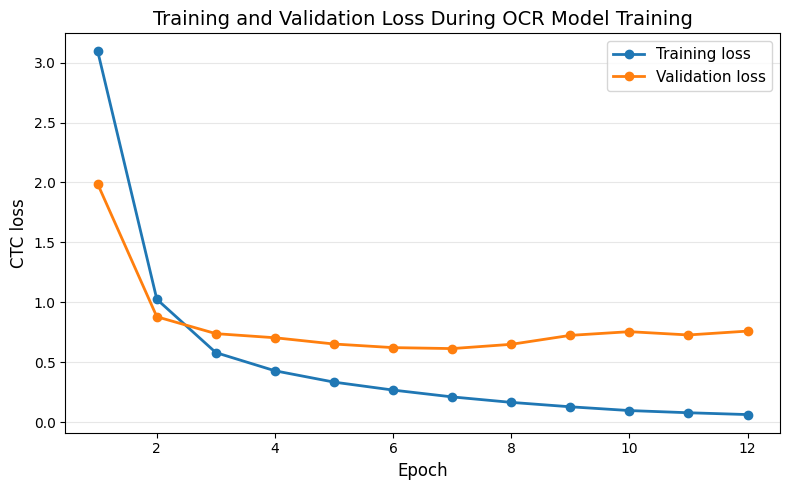

Saved plot to:
/content/drive/MyDrive/OCR project/results/ocr_train_val_loss_curve.png


In [38]:
import os
import matplotlib.pyplot as plt

RESULTS_DIR = "/content/drive/MyDrive/OCR project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.rcParams["font.family"] = "Times New Roman"

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    linewidth=2,
    label="Training loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    linewidth=2,
    label="Validation loss"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("CTC loss", fontsize=12)
plt.title("Training and Validation Loss During OCR Model Training", fontsize=14)

plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

loss_plot_path = os.path.join(RESULTS_DIR, "ocr_train_val_loss_curve.png")

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved plot to:")
print(loss_plot_path)